Hand-drawn Circuit Component Recognition <br>
Author: Apurva Umredkar<br><br>
Step 4: Deploying the trained classifier for real-time circuit component recognition

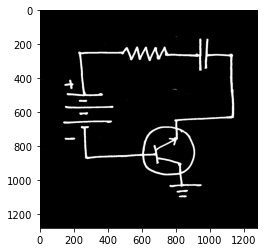

In [1]:
import cv2
import matplotlib.pyplot as plt
from time import sleep 
from IPython.display import clear_output
from CktComponentRecognizer import thresholdImage, recognize
import numpy as np

img = cv2.imread("./ckt2.jpeg", 0)
img = thresholdImage(img)
plt.imshow(img, cmap='gray')


In [2]:
def calcBlackPercent(img):
    # assuming the input image is already in the required inverted binary mode
    amount_black = np.sum((img == 0)*1)
    num_pixels = img.shape[0]*img.shape[1]
    return amount_black * 100 / num_pixels


Black % = 100.0


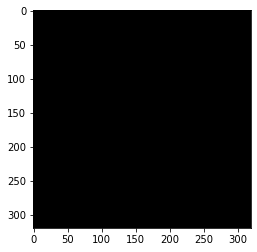

In [3]:
block_size = 320
x_stride = img.shape[0]//10
y_stride = img.shape[1]//50
total_black_percent = calcBlackPercent(img)

for x in range(0,img.shape[0], x_stride):
    if not x > img.shape[0] - block_size: 
        for y in range(0,img.shape[1], y_stride):
            if not y > img.shape[1] - block_size: 
                img_block = img[x:x+block_size, y:y+block_size]
                black_percent = calcBlackPercent(img_block)
                print(f"Black % = {black_percent}")
                if black_percent < total_black_percent: print(recognize(img_block))
                plt.imshow(img_block, cmap='gray')
                plt.show()
                sleep(0.1)
                clear_output(wait=True)